In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import joblib
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("../Datasets/stroke-data.csv")

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
df.shape

(5110, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [5]:
df.describe

<bound method NDFrame.describe of          id  gender   age  hypertension  heart_disease ever_married  \
0      9046    Male  67.0             0              1          Yes   
1     51676  Female  61.0             0              0          Yes   
2     31112    Male  80.0             0              1          Yes   
3     60182  Female  49.0             0              0          Yes   
4      1665  Female  79.0             1              0          Yes   
...     ...     ...   ...           ...            ...          ...   
5105  18234  Female  80.0             1              0          Yes   
5106  44873  Female  81.0             0              0          Yes   
5107  19723  Female  35.0             0              0          Yes   
5108  37544    Male  51.0             0              0          Yes   
5109  44679  Female  44.0             0              0          Yes   

          work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0           Private          Urba

In [7]:
missing = pd.DataFrame({
    "Missing":df.isnull().sum(),
    "Percent":round(df.isnull().mean()*100,2)
})

missing

,Missing,Percent
id,0,0.00
gender,0,0.00
age,0,0.00
hypertension,0,0.00
heart_disease,0,0.00
ever_married,0,0.00
work_type,0,0.00
Residence_type,0,0.00
avg_glucose_level,0,0.00
bmi,201,3.93


In [4]:
df.drop('id',axis=1,inplace=True)

df['stroke'].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

In [ ]:
sns.countplot(x='stroke',data=df)

plt.title("Stroke Distribution")
plt.show()

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(figsize=(15,10))

plt.tight_layout()
plt.show()

In [ ]:
for col in ['age','avg_glucose_level','bmi']:
    
    plt.figure(figsize=(6,3))
    
    sns.boxplot(x=df[col])
    
    plt.show()

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')

plt.show()

In [ ]:
for col in ['age','avg_glucose_level','bmi']:
    
    plt.figure(figsize=(6,4))
    
    sns.boxplot(x='stroke',y=col,data=df)
    
    plt.show()

In [16]:
X = df.drop('stroke',axis=1)

y = df['stroke']

In [17]:
cat_cols = X.select_dtypes(include='object').columns

num_cols = X.select_dtypes(exclude='object').columns

In [18]:
numeric_transformer = Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

In [19]:
categorical_transformer = Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(handle_unknown='ignore'))
])

In [20]:
preprocessor = ColumnTransformer([
    ('num',numeric_transformer,num_cols),
    ('cat',categorical_transformer,cat_cols)
])

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [24]:
lr_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model',LogisticRegression(max_iter=2000))
])

lr_pipeline.fit(X_train,y_train)

pred_lr = lr_pipeline.predict(X_test)

lr_acc = accuracy_score(y_test,pred_lr)

print("Accuracy:",lr_acc)

Accuracy: 0.7514677103718199


In [25]:
rf_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model',RandomForestClassifier(n_estimators=300,random_state=42))
])

rf_pipeline.fit(X_train,y_train)

pred_rf = rf_pipeline.predict(X_test)

rf_acc = accuracy_score(y_test,pred_rf)

print("Accuracy:",rf_acc)

Accuracy: 0.9187866927592955


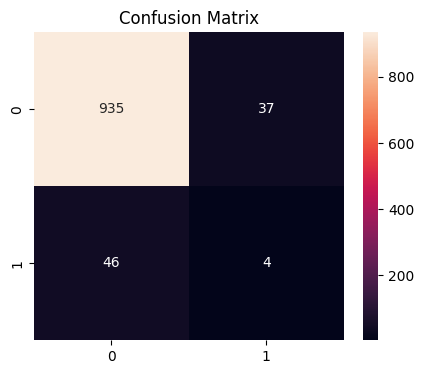

In [31]:
cm = confusion_matrix(y_test,pred_rf)

plt.figure(figsize=(5,4))

sns.heatmap(cm,annot=True,fmt='d')

plt.title("Confusion Matrix")

plt.show()

In [35]:
xgb_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
         n_estimators=500,
         max_depth=4,
         learning_rate=0.03,
         random_state=42,
         eval_metric='logloss'
     ))
])

xgb_pipeline.fit(X_train,y_train)

pred_xgb = xgb_pipeline.predict(X_test)

xgb_acc = accuracy_score(y_test,pred_xgb)

print("Accuracy:",xgb_acc)

Accuracy: 0.9099804305283757


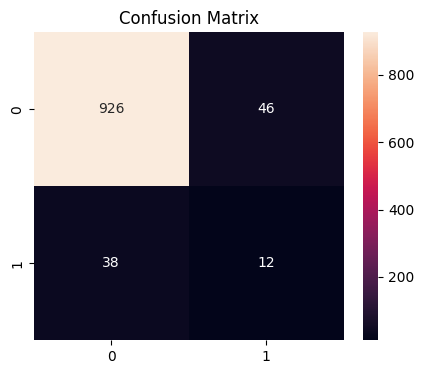

In [32]:
cm = confusion_matrix(y_test,pred_xgb)

plt.figure(figsize=(5,4))

sns.heatmap(cm,annot=True,fmt='d')

plt.title("Confusion Matrix")

plt.show()

In [36]:
results = pd.DataFrame({
    "Model":["Logistic Regression","Random Forest","XGBoost"],
    "Accuracy":[lr_acc,rf_acc,xgb_acc]
})

results.sort_values(by='Accuracy',ascending=False)

,Model,Accuracy
1,Random Forest,0.918787
2,XGBoost,0.909980
0,Logistic Regression,0.751468


In [37]:
joblib.dump(
    xgb_pipeline,
    "stroke_model.pkl"
)

['stroke_model.pkl']